In [ ]:
#Import things to analyse and visualise data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [ ]:
import pandas as pd

# Load the 'all_seasons.csv' file into a DataFrame
df_seasons = pd.read_csv('/content/all_seasons.csv')

# Display the first 5 rows of the DataFrame
display(df_seasons.head())

,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
# Drop rows with any missing values
df_seasons = df_seasons.dropna()

print("DataFrame after dropping rows with missing values:")
display(df_seasons.head())

DataFrame after dropping rows with missing values:


,Unnamed: 0,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


In [ ]:
# Making 'x' my imput and 'y' my output
X = df_seasons[['age', 'gp', 'reb', 'ast', 'net_rating', 'oreb_pct', 'dreb_pct']]
y = df_seasons['pts']

print("Features (X) head:")
display(X.head())

print("Target (y) head:")
display(y.head())

Features (X) head:


,age,gp,reb,ast,net_rating,oreb_pct,dreb_pct
0,22.0,64,1.5,2.4,0.3,0.042,0.071
1,28.0,4,1.3,0.3,8.9,0.030,0.111
2,26.0,41,6.4,1.9,-8.2,0.106,0.185
3,30.0,64,2.8,1.7,-2.7,0.027,0.111
4,23.0,52,1.7,0.3,-14.1,0.102,0.169


Target (y) head:


,pts
0,3.9
1,3.8
2,8.3
3,10.2
4,2.8


In [ ]:
#train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (8792, 7)
Shape of X_test: (2198, 7)
Shape of y_train: (8792,)
Shape of y_test: (2198,)


In [ ]:
#scaling the dataset
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train after scaling:")
display(pd.DataFrame(X_train).head())

print("X_test after scaling:")
display(pd.DataFrame(X_test).head())

X_train after scaling:


,0,1,2,3,4,5,6
0,1.111886,0.411808,-0.056055,-0.848881,-0.494367,1.118121,0.134867
1,-0.503093,-1.801308,-0.602486,-0.233798,0.422214,-0.562735,0.038630
2,-1.195227,-0.931870,-0.434353,-0.401548,1.210151,-0.397017,-0.618991
3,-0.041671,-1.248029,0.070044,-0.904798,-0.679291,1.615276,0.696251
4,-0.733805,-0.615710,0.826640,1.835118,0.446334,-0.562735,-0.201963


X_test after scaling:


,0,1,2,3,4,5,6
0,-0.272382,1.241727,2.045600,-0.066048,-0.470246,0.620967,0.551895
1,-0.964516,-1.880348,-1.148916,0.269452,-0.992858,-1.249281,-0.923742
2,-1.425938,0.965088,1.961533,-0.066048,-0.534568,0.691989,1.113279
3,-0.964516,-0.536670,-0.896717,-0.513381,0.012165,-0.468039,-0.586912
4,-0.733805,0.569888,-0.308254,-0.513381,-0.204920,-0.823149,-0.362358


In [ ]:
#making the model, looks at 5 neighbors
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

print("KNeighborsRegressor model trained successfully.")

KNeighborsRegressor model trained successfully.


In [ ]:
#model predicts points
y_pred = knn.predict(X_test)

print("Predictions (y_pred) made successfully. Here are the first 5 predictions:")
display(y_pred[:5])

Predictions (y_pred) made successfully. Here are the first 5 predictions:


array([15.94210526,  4.82105263, 12.86315789,  3.58421053,  7.80526316])

In [ ]:
#checking how far of the model is the lower the better
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 8.27


In [ ]:
#finding the optimal value of K
import numpy as np

errors = []

for k in range(1, 20):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_squared_error(y_test, y_pred))

best_k = np.argmin(errors) + 1
print("Beste K:", best_k)

Beste K: 13


In [ ]:
#output
print("Aantal trainingsdata:", len(X_train))
print("Aantal testdata:", len(X_test))

Aantal trainingsdata: 8792
Aantal testdata: 2198


In [ ]:
#real vs predicted
results = pd.DataFrame({
    "Echte punten": y_test.values,
    "Voorspelde punten": y_pred
})

display(results.head(10))

,Echte punten,Voorspelde punten
0,12.2,15.942105
1,3.3,4.821053
2,9.9,12.863158
3,3.5,3.584211
4,6.0,7.805263
5,11.5,13.205263
6,11.6,19.752632
7,3.2,3.036842
8,1.6,2.505263
9,2.8,2.742105


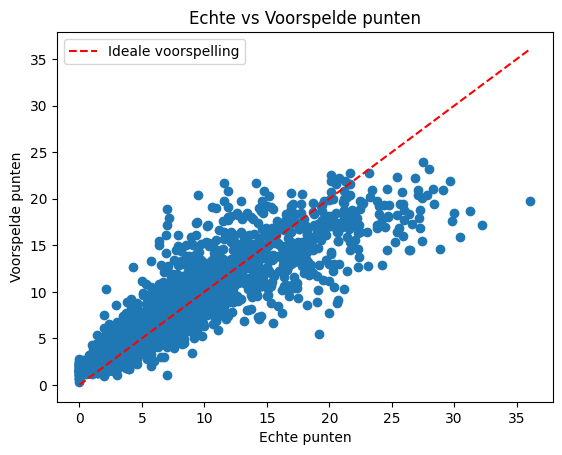

In [ ]:
#visual
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Echte punten")
plt.ylabel("Voorspelde punten")
plt.title("Echte vs Voorspelde punten")

# Add a diagonal line for ideal predictions (y_test = y_pred)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideale voorspelling')
plt.legend()

plt.show()

In [ ]:
#avarage of point difference
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 2.8760445790722122


In [ ]:
#results
print(results.describe())

       Echte punten  Voorspelde punten
count   2198.000000        2198.000000
mean       8.193767           8.167133
std        6.076823           5.050786
min        0.000000           0.263158
25%        3.500000           3.890789
50%        6.600000           7.107895
75%       11.500000          11.540789
max       36.100000          23.915789
